# Assignment 6 – Knock Airport Weather

**Module:** Programming for Data Analytics
This notebook explores temperature and windspeed using hourly data.

**Dataset:** Hourly observations from Knock Airport (station 4935)
**Source:** https://cli.fusio.net/cli/climate_data/webdata/hly4935.csv

---

## Overview

This notebook plots:

### Part A – Temperature

- Hourly temperature
- Mean temperature for each day
- Mean temperature for each month

### Part B – Wind

- Hourly windspeed (with missing data)
- Rolling mean windspeed (e.g. 24-hour rolling mean)
- Maximum windspeed for each day
- Monthly mean of the **daily max** windspeeds

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Make plots a bit larger and easier to read
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 11

# Show all columns if we print a DataFrame
pd.set_option("display.max_columns", None)

In [27]:
import pandas as pd

# URL for Knock Airport hourly climate data (station 4935)
url = "https://cli.fusio.net/cli/climate_data/webdata/hly4935.csv"

# The file has 23 lines of metadata before the real header,
# so we skip those lines and start reading from the header row.
df = pd.read_csv(url, skiprows=23)

print("Shape:", df.shape)
df.head()

Shape: (256434, 21)


/var/folders/j_/ybtclmn96xv9zbzh98s9m3gm0000gp/T/ipykernel_26445/2841901103.py:8: DtypeWarning: Columns (2,10,12,14,15,16,18,19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url, skiprows=23)


,date,ind,rain,ind.1,temp,ind.2,wetb,dewpt,vappr,rhum,msl,ind.3,wdsp,ind.4,wddir,ww,w,sun,vis,clht,clamt
0,10-apr-1996 14:00,0,0.0,0,11.5,0,8.1,3.9,0.0,0,1016.7,0,0,0,0,25,81,0.0,35000,32,5
1,31-jul-1996 08:00,0,0.0,0,11.5,0,11.1,10.7,0.0,0,1011.4,0,0,0,0,25,82,0.0,40000,45,5
2,31-jul-1996 09:00,0,0.0,0,11.6,0,10.7,9.8,0.0,0,1011.4,0,0,0,0,80,81,0.0,8000,32,7
3,31-jul-1996 10:00,0,0.0,0,12.9,0,11.3,9.8,0.0,0,1011.2,0,0,0,0,25,82,0.0,28000,35,6
4,31-jul-1996 11:00,0,0.0,0,14.5,0,10.8,7.0,0.0,0,1011.0,0,0,0,0,2,11,0.0,40000,40,6


In [25]:
# Make sure we have a proper datetime index called 'date'

if "date" in df.columns:
    # Case 1: 'date' is still a normal column
    df["date"] = pd.to_datetime(df["date"], dayfirst=True)
    df = df.sort_values("date").set_index("date")
else:
    # Case 2: 'date' is already the index (so we just convert/sort the index)
    df.index = pd.to_datetime(df.index, dayfirst=True)
    df = df.sort_index()

# Quick check that the index and key columns look OK
print(df.index[:5])
df[["temp", "wdsp"]].head()

DatetimeIndex(['1996-04-10 14:00:00', '1996-07-31 08:00:00',
               '1996-07-31 09:00:00', '1996-07-31 10:00:00',
               '1996-07-31 11:00:00'],
              dtype='datetime64[ns]', name='date', freq=None)


,temp,wdsp
date,,
1996-04-10 14:00:00,11.5,0.0
1996-07-31 08:00:00,11.5,0.0
1996-07-31 09:00:00,11.6,0.0
1996-07-31 10:00:00,12.9,0.0
1996-07-31 11:00:00,14.5,0.0


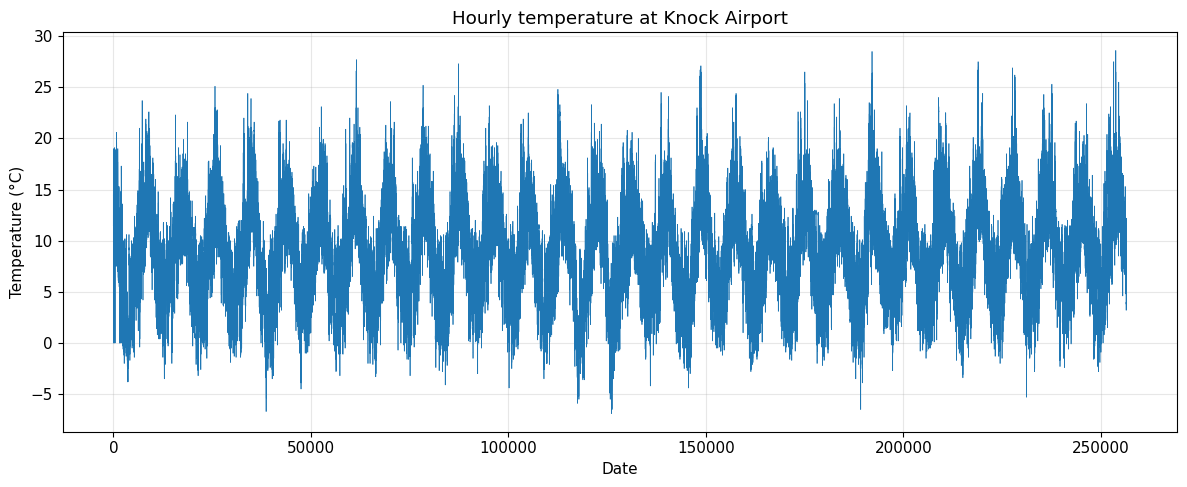

In [28]:
import matplotlib.pyplot as plt

# Plot the hourly air temperature ('temp' column).
plt.figure()
df["temp"].plot(linewidth=0.5)
plt.title("Hourly temperature at Knock Airport")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

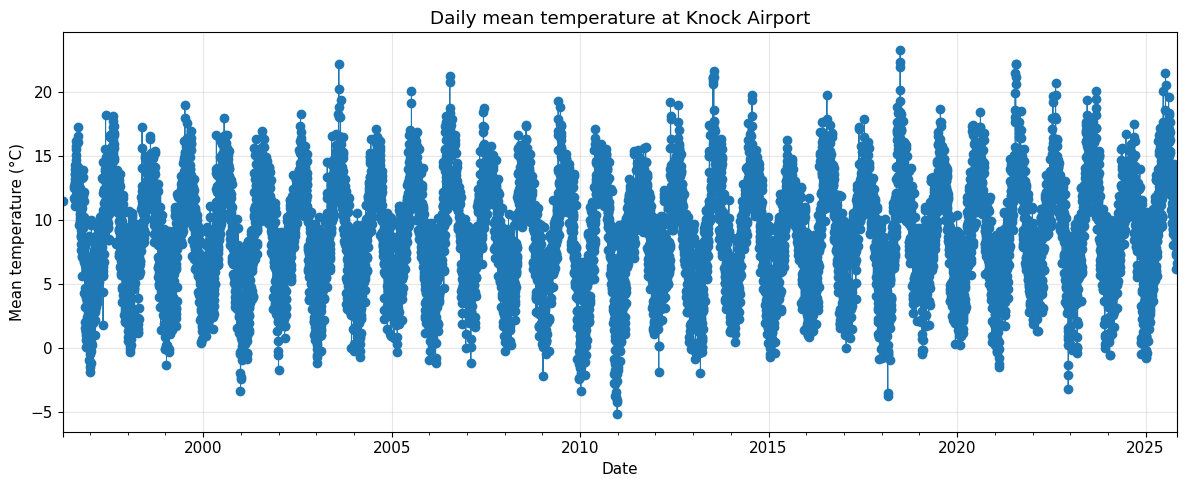

date
1996-04-10    11.5
1996-04-11     NaN
1996-04-12     NaN
1996-04-13     NaN
1996-04-14     NaN
Freq: D, Name: temp, dtype: float64

In [9]:
# Daily mean temperature
daily_mean_temp = df["temp"].resample("D").mean()

plt.figure()
daily_mean_temp.plot(marker="o", linewidth=0.7)
plt.title("Daily mean temperature at Knock Airport")
plt.xlabel("Date")
plt.ylabel("Mean temperature (°C)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

daily_mean_temp.head()

/var/folders/j_/ybtclmn96xv9zbzh98s9m3gm0000gp/T/ipykernel_26445/3625276661.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_mean_temp = df["temp"].resample("M").mean()


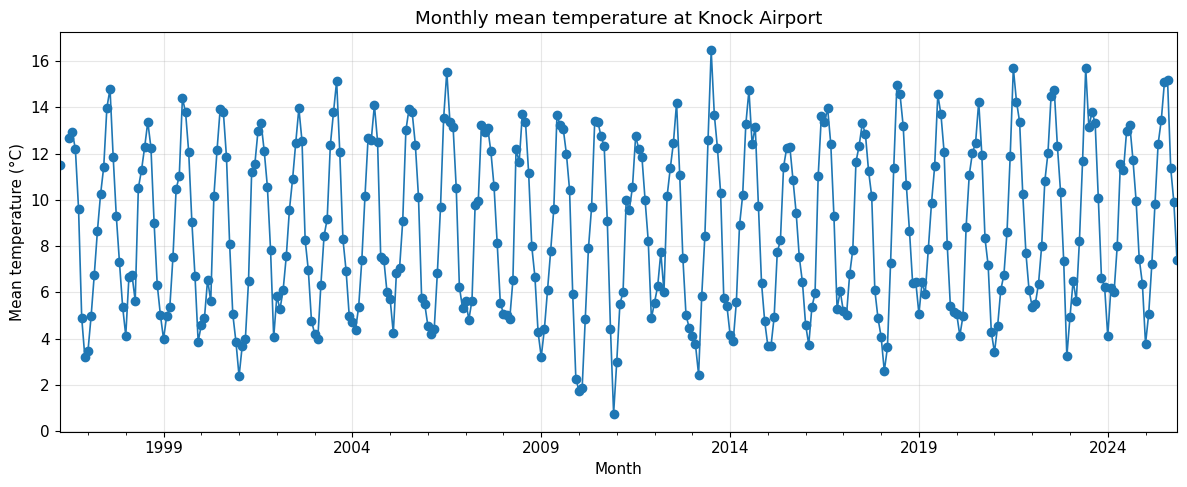

date
1996-04-30    11.500000
1996-05-31          NaN
1996-06-30          NaN
1996-07-31    12.650000
1996-08-31    12.946909
Freq: ME, Name: temp, dtype: float64

In [10]:
# Monthly mean temperature
monthly_mean_temp = df["temp"].resample("M").mean()

plt.figure()
monthly_mean_temp.plot(marker="o", linewidth=1.2)
plt.title("Monthly mean temperature at Knock Airport")
plt.xlabel("Month")
plt.ylabel("Mean temperature (°C)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

monthly_mean_temp.head()

In [11]:
# Convert windspeed column to numeric (coerce errors to NaN)
df["wdsp"] = pd.to_numeric(df["wdsp"], errors="coerce")

df["wdsp"].describe()

count    256384.000000
mean          9.457256
std           4.928617
min           0.000000
25%           6.000000
50%           9.000000
75%          12.000000
max          50.000000
Name: wdsp, dtype: float64

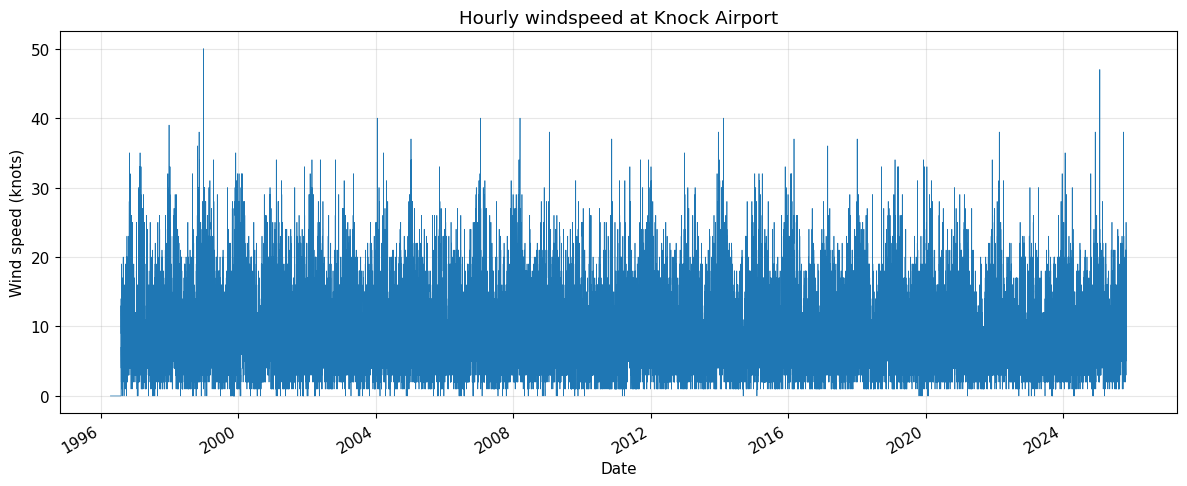

In [12]:
plt.figure()
df["wdsp"].plot(linewidth=0.5)
plt.title("Hourly windspeed at Knock Airport")
plt.xlabel("Date")
plt.ylabel("Wind speed (knots)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

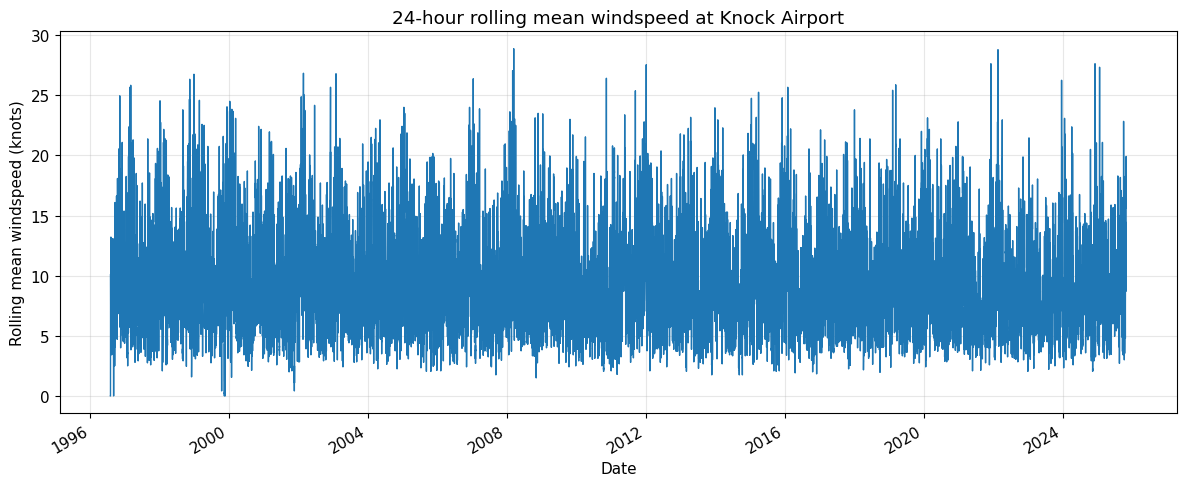

In [13]:
# 24-hour rolling mean windspeed (on hourly data)
rolling_window_hours = 24

rolling_wind = df["wdsp"].rolling(window=rolling_window_hours, min_periods=6).mean()

plt.figure()
rolling_wind.plot(linewidth=1.0)
plt.title(f"{rolling_window_hours}-hour rolling mean windspeed at Knock Airport")
plt.xlabel("Date")
plt.ylabel("Rolling mean windspeed (knots)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

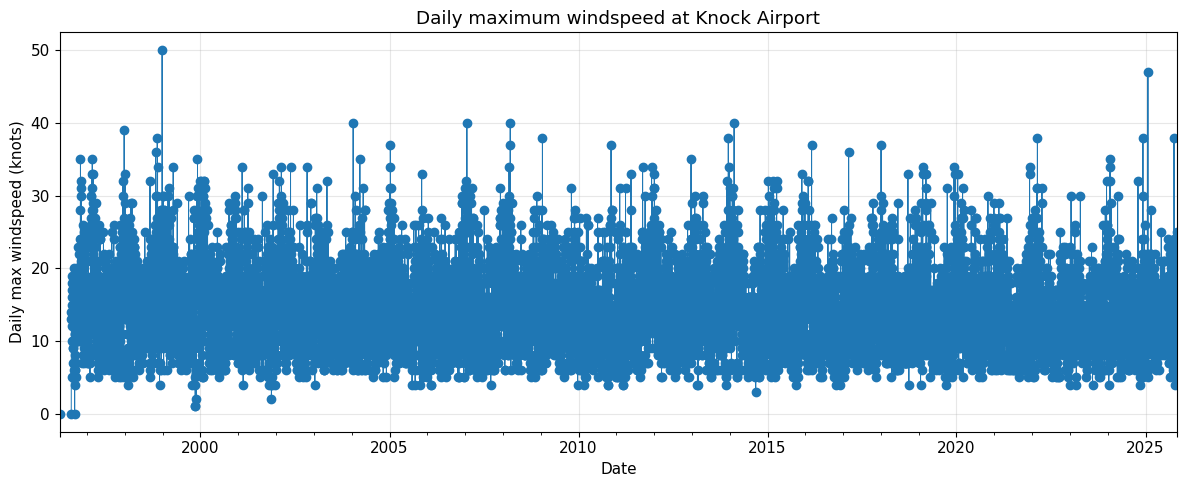

date
1996-04-10    0.0
1996-04-11    NaN
1996-04-12    NaN
1996-04-13    NaN
1996-04-14    NaN
Freq: D, Name: wdsp, dtype: float64

In [14]:
# Daily maximum windspeed
daily_max_wind = df["wdsp"].resample("D").max()

plt.figure()
daily_max_wind.plot(marker="o", linewidth=0.7)
plt.title("Daily maximum windspeed at Knock Airport")
plt.xlabel("Date")
plt.ylabel("Daily max windspeed (knots)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

daily_max_wind.head()

/var/folders/j_/ybtclmn96xv9zbzh98s9m3gm0000gp/T/ipykernel_26445/1519500525.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_mean_daily_max_wind = daily_max_wind.resample("M").mean()


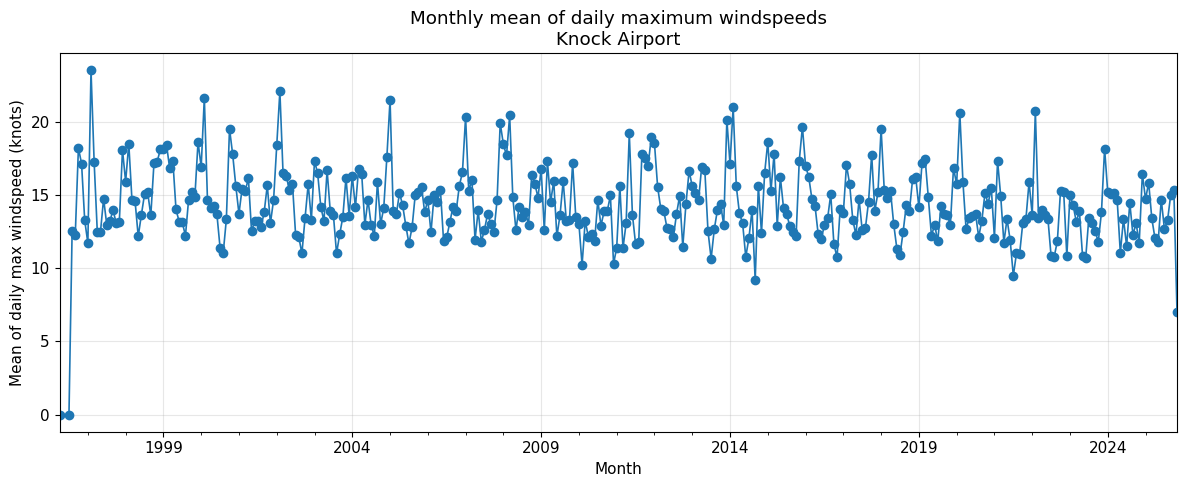

date
1996-04-30     0.000000
1996-05-31          NaN
1996-06-30          NaN
1996-07-31     0.000000
1996-08-31    12.516129
Freq: ME, Name: wdsp, dtype: float64

In [15]:
# Monthly mean of the *daily maximum* windspeeds
monthly_mean_daily_max_wind = daily_max_wind.resample("M").mean()

plt.figure()
monthly_mean_daily_max_wind.plot(marker="o", linewidth=1.2)
plt.title("Monthly mean of daily maximum windspeeds\nKnock Airport")
plt.xlabel("Month")
plt.ylabel("Mean of daily max windspeed (knots)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

monthly_mean_daily_max_wind.head()